# 3.  Codificación de variables

Conjunto de datos: titanic (incluido en seaborn)

Este conjunto de datos es excelente para trabajar con variables categóricas.

In [26]:
# Importar librerías necesarias
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

In [27]:
# Cargar el conjunto de datos
data = sns.load_dataset('titanic')

In [28]:
# Visualizar las primeras filas
print("Conjunto de datos Titanic:")
data.head()

Conjunto de datos Titanic:


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [29]:
# Seleccionar columnas categóricas
categorical_cols = ['sex', 'embarked', 'class']

In [30]:
# Codificar con LabelEncoder
label_encoder = LabelEncoder()
data['sex_label'] = label_encoder.fit_transform(data['sex'])

In [31]:
# Codificar con OneHotEncoder
onehot_encoder = pd.get_dummies(data['embarked'], prefix='embarked')

In [32]:
# Combinar con el conjunto original
data = pd.concat([data, onehot_encoder], axis=1)

data

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_label,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,1,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,0,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0,False,False,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True,1,False,False,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True,0,False,False,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False,0,False,False,True
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True,1,True,False,False


# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre LabelEncoder y OneHotEncoder?

**1. LabelEncoder** (Aplicado a 'sex')  

Este tipo de codificación asigna un número entero único y secuencial a cada categoría única (en este caso, `Male ➔ 1`, `Female ➔ 0`). Introduce un orden jerárquico artificial implícito (\(0 < 1 < 2\)). Es ideal para variables categóricas ordinales (que tienen un orden natural, como niveles de estudio). Si se usa en variables nominales con muchas categorías, los algoritmos de Machine Learning pueden interpretar erróneamente que una categoría es "mayor" o "más importante" que otra. En el caso de `'sex'`, al ser binaria (solo dos opciones), este impacto negativo es mínimo.

**2. OneHotEncoder** (Aplicado a 'embarked')  

Este tipo de codificaición crea una nueva columna binaria (`0` o `1`) por cada categoría única presente en la variable. En este caso, el puerto de embarque tiene tres opciones (C, Q, S), por lo cual se generaron tres columnas independientes (`embarked_C`, `embarked_Q`, `embarked_S`).Aqui no introduce ninguna jerarquía ni orden artificial. Cada categoría se trata de manera completamente independiente y equitativa. Es la técnica adecuada para variables categóricas nominales donde no existe una relación de orden entre las opciones, evitando que el modelo asuma relaciones matemáticas incorrectas.


### 2. Crea una gráfica de barras comparando las frecuencias de 'sex' antes y después de la codificación con LabelEncoder.

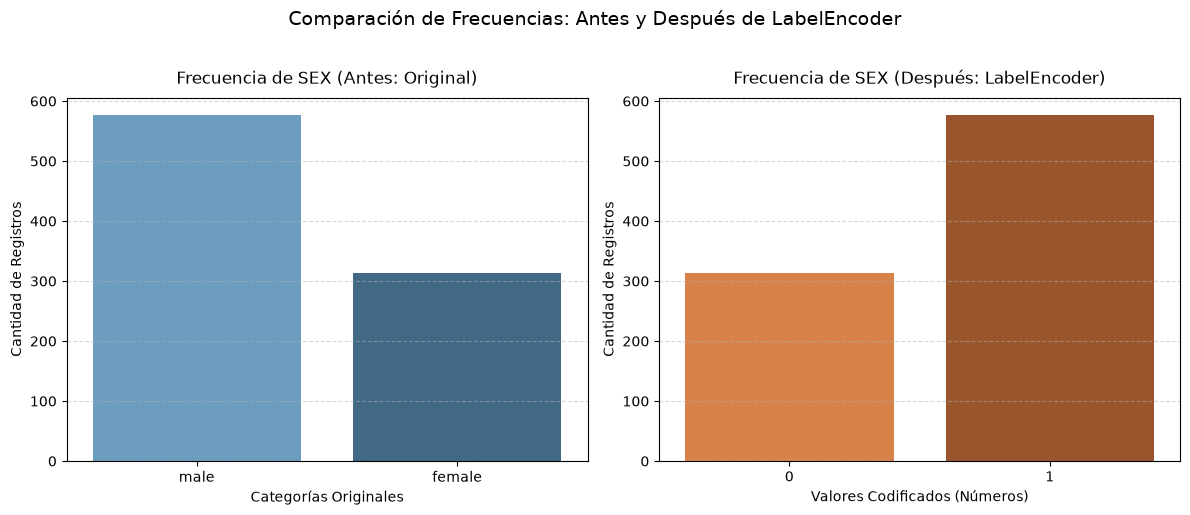

In [33]:
# Configurar figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Gráfica 1: Antes de la codificación (Original) ---
sns.countplot(x=data['sex'], hue=data['sex'], ax=ax1, palette='Blues_d', legend=False)
ax1.set_title('Frecuencia de SEX (Antes: Original)', fontsize=12, pad=10)
ax1.set_xlabel('Categorías Originales')
ax1.set_ylabel('Cantidad de Registros')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Gráfica 2: Después de la codificación (LabelEncoder) ---
sns.countplot(x=data['sex_label'], hue=data['sex_label'], ax=ax2, palette='Oranges_d', legend=False)
ax2.set_title('Frecuencia de SEX (Después: LabelEncoder)', fontsize=12, pad=10)
ax2.set_xlabel('Valores Codificados (Números)')
ax2.set_ylabel('Cantidad de Registros')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle('Comparación de Frecuencias: Antes y Después de LabelEncoder', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



### 3. Utiliza OneHotEncoder para codificar la columna 'class'. ¿Qué ventajas tiene este enfoque frente a LabelEncoder?

La principal ventaja de OneHotEncoder frente a LabelEncoder es que evita introducir un orden jerárquico o matemático falso entre las categorías. Al crear una columna binaria independiente para cada opción, el modelo trata a todas las variables de forma equitativa sin asumir que una categoría es "mayor" o "mejor" que otra (como sí ocurre con los números secuenciales de LabelEncoder), lo cual puede prevenir sesgos y cálculos matemáticos incorrectos en la mayoría de los algoritmos de Machine Learning.

En el caso de la columna `class`, considero que  LabelEncoder podría ser superior a OneHotEncoderm. En dataset Titanic las clases (First, Second, Third) no son categorías sin relación, sno que representan explícitamente el estatus económico y la ubicación física en el barco. Hay una jerarquía matemática real: la Primera clase tenía privilegios de evacuación que la Tercera clase no tenía.

In [35]:
# Codificar la columna 'class' con OneHotEncoder
onehot_class = pd.get_dummies(data['class'], prefix='class')

# Combinar con el conjunto original
data = pd.concat([data, onehot_class], axis=1)

data.head(5)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,...,sex_label,embarked_C,embarked_Q,embarked_S,class_First,class_Second,class_Third,class_First,class_Second,class_Third
0,0,3,male,22.0,1,0,7.2500,S,Third,man,...,1,False,False,True,False,False,True,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,...,0,True,False,False,True,False,False,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,...,0,False,False,True,False,False,True,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,...,0,False,False,True,True,False,False,True,False,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,...,1,False,False,True,False,False,True,False,False,True


### 4. Si quisieras aplicar un modelo de aprendizaje automático, ¿qué tipo de codificación elegirías para las variables categóricas? Explica tu respuesta.

Para aplicar un modelo de aprendizaje automático, no elegiría una sola técnica de forma global, sino que combinaría OneHotEncoder y LabelEncoder o mapeo manual dependiendo de la naturaleza de cada variable en el conjunto de datos:

- Para variables categóricas nominales, que son aquellas que no tienen ningún orden o jerarquía natural entre sus opciones (como el puerto de embarque 'embarked', géneros musicales o colores), elegiría OneHotEncoder. Esto se debe a que este método crea columnas independientes de presencia/ausencia (0 o 1) para cada categoría, asegurando que el algoritmo trate a todas las opciones de manera equitativa y evitando que asuma relaciones matemáticas o prioridades falsas que estropeen el aprendizaje del modelo.

- Para variables categóricas ordinales, que son aquellas donde sí existe un orden lógico, una escala socioeconómica o una jerarquía clara (como la variable 'class' del Titanic o niveles de estudio), elegiría una codificación ordinal mediante LabelEncoder. En este escenario, inyectar el orden numérico explícito (como 1, 2, 3) es una ventaja crítica, ya que le ayuda al algoritmo a entender la estructura lógica del problema desde el inicio, reduce el riesgo de sobreajuste y optimiza el rendimiento del modelo al reflejar un comportamiento real de los datos.
